# Autoencoders

## Real-World Scenario: Compact Representations of Single-Cell Gene Expression

A modern single-cell RNA-seq experiment yields a profile $\mathbf{x}_n \in \mathbb{R}^D$ for each of $N$ cells, where $D$ is in the thousands of genes. Most of the variation is driven by a handful of biological factors — cell type, cycle phase, stress response — so the data lies near a much lower-dimensional manifold of dimensionality $L \ll D$. PCA / FA model that manifold *linearly*; autoencoders model it with neural networks and so handle non-linear structure.

We work through PML §20.3:

1. **Encoder–decoder framework** and the reconstruction loss
2. **Bottleneck autoencoders** (§20.3.1) — linear AE recovers PCA; nonlinear AE strictly more powerful
3. **Denoising autoencoders** (§20.3.2) — robust to dropout noise; residual approximates $\nabla_\mathbf{x} \log p(\mathbf{x})$
4. **Contractive autoencoders** (§20.3.3) — Frobenius-norm penalty on $\partial f_e / \partial \mathbf{x}$
5. **Sparse autoencoders** (§20.3.4) — activity regularisation, $\ell_1$ vs KL-to-target
6. **Variational autoencoders** (§20.3.5) — probabilistic AE that supports sampling and interpolation, trained via ELBO + reparameterization trick

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

device = torch.device('cpu')
print(f'torch {torch.__version__}  ·  numpy {np.__version__}')

torch 2.1.1  ·  numpy 1.26.4


## Key Formulas from PML Chapter 20.3

**Encoder / decoder** (Section 20.3 intro). Given encoder $f_e: \mathbb{R}^D \to \mathbb{R}^L$ and decoder $f_d: \mathbb{R}^L \to \mathbb{R}^D$, reconstruction is $r(\mathbf{x}) = f_d(f_e(\mathbf{x}))$ and the loss is

$$\mathcal{L}(\boldsymbol{\theta}) = \|r(\mathbf{x}) - \mathbf{x}\|_2^2 \quad\text{or, more generally,}\quad -\log p(\mathbf{x}\mid r(\mathbf{x})).$$

**Linear bottleneck** (§20.3.1). With $\mathbf{z} = \mathbf{W}_1\mathbf{x}$ and $\hat{\mathbf{x}} = \mathbf{W}_2 \mathbf{z}$, the loss-minimising $\mathbf{W}_1, \mathbf{W}_2$ project onto the top $L$ eigenvectors of the covariance — equivalent to PCA.

**Denoising** (§20.3.2). Train on corrupted inputs $\tilde{\mathbf{x}} \sim p_c(\cdot \mid \mathbf{x})$ to recover $\mathbf{x}$; for Gaussian corruption $\sigma \to 0$, $r(\mathbf{x}) - \mathbf{x} \approx \nabla_\mathbf{x} \log p(\mathbf{x})$.

**Contractive** (§20.3.3). Add the encoder-Jacobian penalty (Eq. 20.93)

$$\Omega(\mathbf{z}, \mathbf{x}) = \lambda \left\| \frac{\partial f_e(\mathbf{x})}{\partial \mathbf{x}} \right\|_F^2.$$

**Sparse activity** (§20.3.4). Either $\ell_1$ on the codes $\Omega(\mathbf{z}) = \lambda \|\mathbf{z}\|_1$, or KL of the average activation $q_k = \frac{1}{N} \sum_n z_{n,k}$ to a target $p$:

$$\Omega = \lambda \sum_k \mathrm{KL}\big(p \,\|\, q_k\big).$$

**VAE** (§20.3.5). Generative model $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$, $p_\theta(\mathbf{x}\mid \mathbf{z}) = \mathcal{N}(\mathbf{x} \mid f_d(\mathbf{z}), \sigma^2 \mathbf{I})$, inference $q_\phi(\mathbf{z}\mid \mathbf{x}) = \mathcal{N}(\mu_\phi(\mathbf{x}), \mathrm{diag}(\sigma_\phi^2(\mathbf{x})))$. Trained by maximising the ELBO (Eq. 20.98):

$$\mathrm{ELBO}(\theta, \phi; \mathbf{x}) = \mathbb{E}_{q_\phi}\big[\log p_\theta(\mathbf{x}\mid \mathbf{z})\big] - D_{\mathrm{KL}}\!\big(q_\phi(\mathbf{z}\mid \mathbf{x}) \,\|\, p(\mathbf{z})\big).$$

Reparameterization trick (Eq. 20.101): $\mathbf{z} = \mu_\phi(\mathbf{x}) + \sigma_\phi(\mathbf{x}) \odot \boldsymbol{\epsilon}$, $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.

## 1. Synthetic Single-Cell Gene Expression Manifold

We simulate $N = 3000$ cells across $D = 64$ genes, where the **biological state** of each cell lies on a 2-dimensional curved manifold (the cell-cycle ring × cell-type axis). Each gene's expression is a *non-linear* function of that latent state, so the manifold cannot be captured by a linear method like PCA.

The manifold is generated by:

- $\theta_n \sim \mathrm{Uniform}(0, 2\pi)$  — cell-cycle phase
- $r_n \sim \mathrm{Uniform}(0.5, 1.0)$ + small jitter — cell-type axis (radius)
- 4 latent gene-program activations: $a_1 = r\cos\theta$, $a_2 = r\sin\theta$, $a_3 = r$, $a_4 = \sin(2\theta)$
- Each of the $D=64$ genes is a random non-linear combination $x_d = \tanh(\mathbf{w}_d^\top \mathbf{a}) + \epsilon_d$.

This gives a low-dimensional curved manifold embedded non-linearly in 64-d gene space.

cells: 3000   ·   genes: 64   ·   train/val: 2400/600


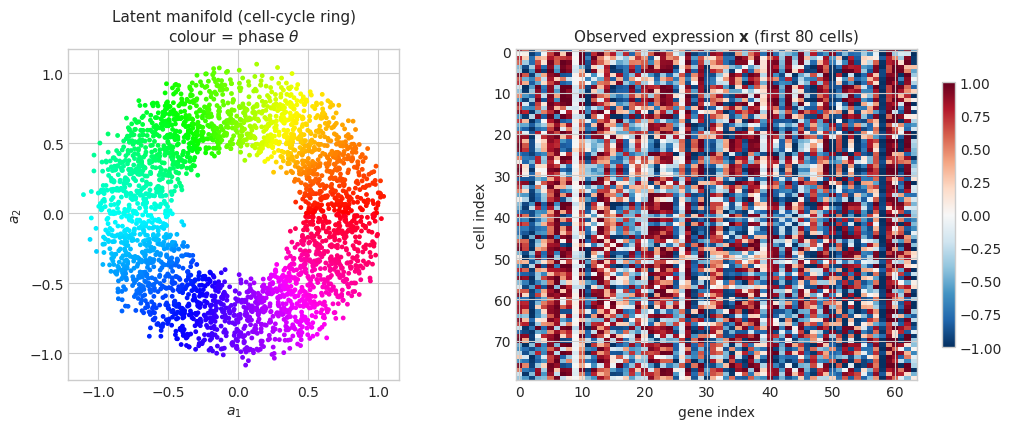

In [ ]:
def make_cells(N, D, noise=0.05, seed=0):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2*np.pi, N)
    r = rng.uniform(0.5, 1.0, N) + 0.05 * rng.standard_normal(N)
    a = np.stack([ # shape : (N, 4)
        r * np.cos(theta),
        r * np.sin(theta),
        r,
        np.sin(2 * theta),
    ], axis=1)
    W_gen = rng.standard_normal((D, 4))
    X = np.tanh(a @ W_gen.T) + noise * rng.standard_normal((N, D))
    return X.astype(np.float32), theta.astype(np.float32), r.astype(np.float32)

N, D = 3000, 64
X, theta, r = make_cells(N, D, noise=0.05, seed=0)

# Train / val split
perm = np.random.permutation(N)
n_tr = 2400
tr, val = perm[:n_tr], perm[n_tr:]

X_t = torch.from_numpy(X)
loader = DataLoader(TensorDataset(X_t[tr]), batch_size=128, shuffle=True)
loader_val = DataLoader(TensorDataset(X_t[val]), batch_size=256)

print(f'cells: {N}   ·   genes: {D}   ·   train/val: {n_tr}/{N-n_tr}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(np.cos(theta) * r, np.sin(theta) * r, c=theta, cmap='hsv', s=6)
axes[0].set_title('Latent manifold (cell-cycle ring)\ncolour = phase $\\theta$', fontsize=11)
axes[0].set_aspect('equal'); axes[0].set_xlabel('$a_1$'); axes[0].set_ylabel('$a_2$')

im = axes[1].imshow(X[:80], aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xlabel('gene index'); axes[1].set_ylabel('cell index')
axes[1].set_title('Observed expression $\\mathbf{x}$ (first 80 cells)', fontsize=11)
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout(); plt.show()

### Biology Quick-Start Primer for §1

If you came in from the math/ML side, here is just enough cell biology to make the synthetic dataset above feel like a real scRNA-seq experiment.

#### What single-cell RNA-seq actually measures

A **single-cell RNA-seq** (scRNA-seq) experiment dissociates a tissue into thousands of individual cells, captures the messenger-RNA (mRNA) molecules in each one, and counts how many copies of each gene's mRNA were present. Each cell is summarised by a vector $\mathbf{x}_n \in \mathbb{R}^D$ of (log-)normalised counts across $D$ genes — typically $D \approx 2{,}000$–$20{,}000$. **High mRNA count** for gene $d$ is interpreted as gene $d$ being *expressed* in cell $n$, i.e. the cell is currently producing the protein it codes for.

#### The two latent axes in our toy data

The synthetic data has just two effective biological axes, encoded as a polar coordinate $(r, \theta)$, plus a downstream four-dimensional "gene-program" vector $\mathbf{a}$ that the genes actually read off. Below we unpack each one.

##### $\theta_n \in [0, 2\pi)$ — the cell-cycle phase

A dividing cell goes through a cyclic sequence of states known as the **cell cycle**:

$$\text{G1} \;\to\; \text{S} \;\to\; \text{G2} \;\to\; \text{M} \;\to\; \text{G1} \;\to\; \cdots$$

- **G1** — cell grows and prepares to copy its DNA
- **S** — DNA replication
- **G2** — second growth phase, prepares for division
- **M** — mitosis: the cell physically splits into two

Each phase has a characteristic set of genes turned on (cyclins, CDKs, replication machinery, mitotic regulators...). Because the sequence loops back on itself, we parameterise it by an **angle** $\theta$ on a circle: $\theta = 0$ might mean early G1, $\theta = \pi/2$ S-phase, $\theta = \pi$ G2, $\theta = 3\pi/2$ mitosis, and $\theta = 2\pi$ wraps back to early G1. **The crucial topological fact: $\theta = 0$ and $\theta = 2\pi$ are the same biological state.** Linear methods like PCA cannot represent this — they would have to artificially "cut" the circle. Nonlinear AEs can.

In the data we sample $\theta_n \sim \mathrm{Uniform}(0, 2\pi)$ — i.e. the cells are caught at random moments of their cycles, exactly as in a real asynchronously-growing culture.

##### $r_n \in [0.5, 1.0]$ — the cell-type / activity axis

The radius represents a *separate* biological axis that cells move along independently of cell-cycle phase. Concretely you can read it as one of:

- a **continuous cell-type spectrum** — e.g. progenitor (low $r$) → fully differentiated (high $r$);
- an **activity / metabolic level** — e.g. quiescent (low $r$) → highly active (high $r$);
- the **strength of an external signal** — e.g. low $r$ = no stimulus, high $r$ = saturated response.

Geometrically, when we put $(r, \theta)$ on the same plane we get a **filled annulus** (a ring with thickness): every cell is on *some* cell-cycle ring, but cells of different types live on rings of different radii. The two latent axes are biologically independent — a progenitor and a differentiated cell can each be in any phase of the cell cycle.

We sample $r_n \sim \mathrm{Uniform}(0.5, 1.0)$ plus a tiny Gaussian jitter, so the data lies in a thin annulus.

##### $\mathbf{a} = (a_1, a_2, a_3, a_4)$ — gene-program activations

Real cells don't directly read off $r$ and $\theta$. Instead, the latent state activates a handful of **gene programs** — co-regulated sets of genes that get switched on together by the same upstream regulator. We model four of them:

| Program | Formula | Biological reading |
|---|---|---|
| $a_1 = r\cos\theta$ | Cartesian $x$ on the cell-cycle plane | Markers high in the **G1/G2** half of the cycle, scaled by activity |
| $a_2 = r\sin\theta$ | Cartesian $y$ on the cell-cycle plane | Markers high in the **S/M** half of the cycle, scaled by activity |
| $a_3 = r$ | radius | A pure **activity / cell-type** program — independent of cycle phase |
| $a_4 = \sin 2\theta$ | second harmonic of phase | A program that fires **twice per cycle** (e.g. peaks once in S, once in M) |

Why split it like this? Because real biological readouts often *aren't* pure $\cos\theta$ — many cell-cycle genes have asymmetric or double-peaked dynamics that need higher harmonics ($\sin 2\theta$, $\cos 2\theta$, ...) to describe. By including $a_4$ we force the manifold to be slightly more wrinkled than a clean ring — exactly the kind of structure that defeats PCA but that a nonlinear AE can absorb.

##### From $\mathbf{a}$ to observed gene expression $\mathbf{x}$

Each of the $D = 64$ genes reads a *random* linear combination of the four programs and squashes it through $\tanh$:

$$x_d = \tanh\!\big(\mathbf{w}_d^\top \mathbf{a}\big) + \epsilon_d, \qquad \mathbf{w}_d \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_4).$$

This mimics how a real gene integrates inputs from several transcription factors (the linear part) and saturates at high or low expression (the $\tanh$). The result: a 2-dimensional latent manifold ($r, \theta$) lifted into a curved 4-d gene-program space, then non-linearly embedded in 64-d gene space.

#### Why gene expression is a nonlinear function of state

Every gene is wired into regulatory circuitry — transcription factors, microRNAs, chromatin state, feedback loops — that **saturates**. Once enough activator is present, expression plateaus; once enough repressor is present, it floors at zero. Real expression curves look very similar to $\tanh$ (Hill functions, sigmoidal dose-response). This is why **linear methods like PCA underfit single-cell data**: they cannot bend the latent space.

#### What "$D = 64$ genes" buys us

Real experiments measure thousands of genes, but the *effective* number of independently-varying directions is much smaller because genes are co-regulated in **gene programs** (sets of genes turned on together by the same transcription factors). Dimensionality reduction exploits exactly this redundancy. Our $D = 64$ keeps the math fast while preserving the key structure: many measured features, very few latent factors.

#### Why dropout matters (preview of §4)

scRNA-seq has **low capture efficiency**: only ~10–30% of mRNA molecules in a cell are actually counted, so many genes that *are* expressed get reported as zero. This is called **dropout**, and it is the single biggest source of noise in the data — exactly why a *denoising* autoencoder is the natural model class for scRNA-seq imputation tools like scVI, MAGIC, and DCA.

#### Take-aways for the rest of the notebook

- The "manifold" we will be learning is the joint set of biologically-realisable expression states — concretely a thin annulus parameterised by $(r, \theta)$.
- The `theta` colouring in every embedding plot tracks the **cell-cycle phase** — a smooth embedding should preserve this circular structure.
- The "cells" we sample from the VAE in §8 should be read as **synthetic cells from the learned generative model** — useful in practice for data augmentation, in-silico perturbation experiments, and benchmarking downstream pipelines.


## 2. Bottleneck Autoencoder — Linear Case Recovers PCA

A **linear** AE has $\mathbf{z} = \mathbf{W}_1 \mathbf{x}$, $\hat{\mathbf{x}} = \mathbf{W}_2 \mathbf{z}$ and minimises $\sum_n \|\mathbf{x}_n - \mathbf{W}_2\mathbf{W}_1\mathbf{x}_n\|^2$. The minimum is achieved when $\mathbf{W}_2\mathbf{W}_1$ is the projection onto the top-$L$ eigenvectors of $\hat{\boldsymbol\Sigma}$ — the PCA solution (Section 20.3.1 / [BH89]).

We train a linear AE by gradient descent and verify it reaches the **same reconstruction loss** as PCA.

Linear AE final MSE : 0.10525
PCA   reconstruction MSE: 0.10519
difference              : 6.31e-05


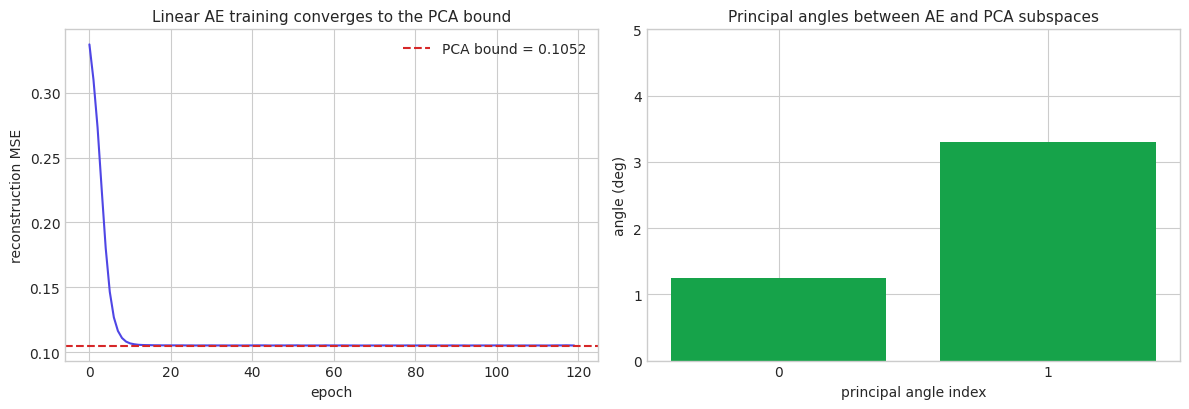

In [3]:
class LinearAE(nn.Module):
    def __init__(self, D, L):
        super().__init__()
        self.enc = nn.Linear(D, L, bias=False)
        self.dec = nn.Linear(L, D, bias=False)
    def forward(self, x):
        return self.dec(self.enc(x))

def train(model, loader, n_epochs=80, lr=1e-2, loss_fn=None):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = loss_fn or (lambda m, x: ((m(x) - x) ** 2).mean())
    history = []
    for ep in range(n_epochs):
        model.train()
        ep_loss = 0.0
        for (xb,) in loader:
            opt.zero_grad()
            loss = loss_fn(model, xb)
            loss.backward()
            opt.step()
            ep_loss += loss.item() * xb.size(0)
        history.append(ep_loss / len(loader.dataset))
    return history

# Center the data first, since linear AE without bias recovers PCA only on centered inputs.
X_mean = X_t[tr].mean(0, keepdim=True)
loader_c = DataLoader(TensorDataset(X_t[tr] - X_mean), batch_size=128, shuffle=True)

L = 2
ae_lin = LinearAE(D, L)
hist_lin = train(ae_lin, loader_c, n_epochs=120, lr=5e-3)

# Compare to PCA
Xc = (X_t[tr] - X_mean).numpy()
S = (Xc.T @ Xc) / Xc.shape[0]
evals, evecs = np.linalg.eigh(S)
evals = evals[::-1]; evecs = evecs[:, ::-1]
W_pca = evecs[:, :L]
recon_pca = Xc @ W_pca @ W_pca.T
mse_pca = ((recon_pca - Xc) ** 2).mean()
mse_ae = hist_lin[-1]

print(f'Linear AE final MSE : {mse_ae:.5f}')
print(f'PCA   reconstruction MSE: {mse_pca:.5f}')
print(f'difference              : {abs(mse_ae - mse_pca):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(hist_lin, color='#4f46e5', lw=1.5)
axes[0].axhline(mse_pca, color='#d62728', ls='--', label=f'PCA bound = {mse_pca:.4f}')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('reconstruction MSE')
axes[0].set_title('Linear AE training converges to the PCA bound', fontsize=11)
axes[0].legend()

# Subspace match: angle between AE encoder rows and PCA top-L eigvecs
W1 = ae_lin.enc.weight.detach().numpy()
# orthonormalise both bases and compare via principal angles
Q_ae, _ = np.linalg.qr(W1.T)
Q_pca, _ = np.linalg.qr(W_pca)
sv = np.linalg.svd(Q_pca.T @ Q_ae, compute_uv=False)
angles_deg = np.degrees(np.arccos(np.clip(sv, -1, 1)))
axes[1].bar(np.arange(L), angles_deg, color='#16a34a')
axes[1].set_xticks(np.arange(L))
axes[1].set_xlabel('principal angle index'); axes[1].set_ylabel('angle (deg)')
axes[1].set_title('Principal angles between AE and PCA subspaces', fontsize=11)
axes[1].set_ylim(0, 5)
plt.tight_layout(); plt.show()

## 3. Nonlinear Bottleneck AE — Strictly More Powerful than PCA

Once we add nonlinearities the AE can fold a curved manifold, which a linear projection can't. We train a small MLP autoencoder

$$f_e(\mathbf{x}) = \tanh(\mathbf{W}_2 \tanh(\mathbf{W}_1 \mathbf{x})),\qquad f_d(\mathbf{z}) = \mathbf{W}_4 \tanh(\mathbf{W}_3 \mathbf{z})$$

with bottleneck $L=2$ — same as the linear case, so any improvement comes purely from non-linearity.

Validation MSE  ·  PCA L=2     : 0.1070
Validation MSE  ·  nonlinear AE : 0.0060
improvement                    : 94.4%


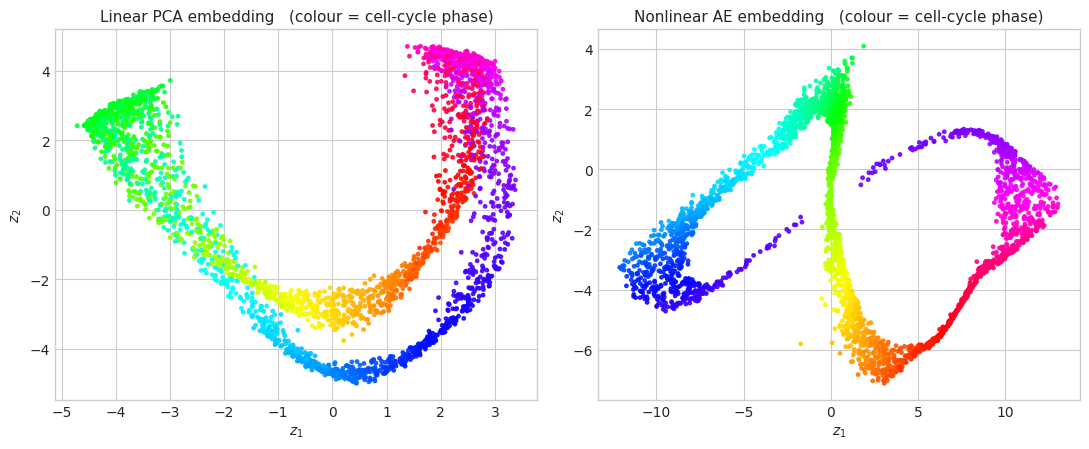

In [4]:
class MLPAutoEncoder(nn.Module):
    def __init__(self, D, hidden, L):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(D, hidden), nn.Tanh(),
            nn.Linear(hidden, L),
        )
        self.dec = nn.Sequential(
            nn.Linear(L, hidden), nn.Tanh(),
            nn.Linear(hidden, D),
        )
    def encode(self, x): return self.enc(x)
    def decode(self, z): return self.dec(z)
    def forward(self, x): return self.dec(self.enc(x))

ae_nl = MLPAutoEncoder(D, hidden=32, L=2)
hist_nl = train(ae_nl, loader, n_epochs=200, lr=2e-3)

# Validation MSE
def mse(model, X):
    with torch.no_grad():
        return ((model(X) - X) ** 2).mean().item()

mse_nl_val = mse(ae_nl, X_t[val])

# PCA on the (uncentered) training data for a fair val MSE comparison
mu = X_t[tr].mean(0).numpy()
W_pca = np.linalg.eigh(np.cov(X[tr].T))[1][:, -2:]  # top 2
recon_val_pca = (X[val] - mu) @ W_pca @ W_pca.T + mu
mse_pca_val = ((recon_val_pca - X[val]) ** 2).mean()

print(f'Validation MSE  ·  PCA L=2     : {mse_pca_val:.4f}')
print(f'Validation MSE  ·  nonlinear AE : {mse_nl_val:.4f}')
print(f'improvement                    : {(mse_pca_val - mse_nl_val)/mse_pca_val*100:.1f}%')

# Visualise embeddings
with torch.no_grad():
    Z_nl = ae_nl.encode(X_t).numpy()
Z_pca = (X - mu) @ W_pca

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, Z, title in zip(axes, [Z_pca, Z_nl], ['Linear PCA embedding', 'Nonlinear AE embedding']):
    ax.scatter(Z[:, 0], Z[:, 1], c=theta, cmap='hsv', s=6, alpha=0.85)
    ax.set_title(title + '   (colour = cell-cycle phase)', fontsize=11)
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
plt.tight_layout(); plt.show()

The nonlinear AE unrolls the cell-cycle ring into a strip whose horizontal axis tracks $\theta$ — something a linear method cannot do. Lower validation MSE confirms the manifold is genuinely non-linear.

## 4. Denoising Autoencoder (§20.3.2)

Single-cell data is famously corrupted by **dropout** — many true counts are read as zero because of low capture efficiency. We simulate this and train an AE on the corrupted inputs to predict the clean targets:

$$\mathcal{L} = \mathbb{E}_{\mathbf{x}, \tilde{\mathbf{x}} \sim p_c}\big[\|f_d(f_e(\tilde{\mathbf{x}})) - \mathbf{x}\|^2\big].$$

This forces the AE to use neighbourhood structure to fill in missing values — *exactly* the imputation task in scRNA-seq workflows.

corruption MSE                              : 0.1513
AE trained on clean data, applied to noisy  : 0.0446
DAE trained on noisy → clean                : 0.0062


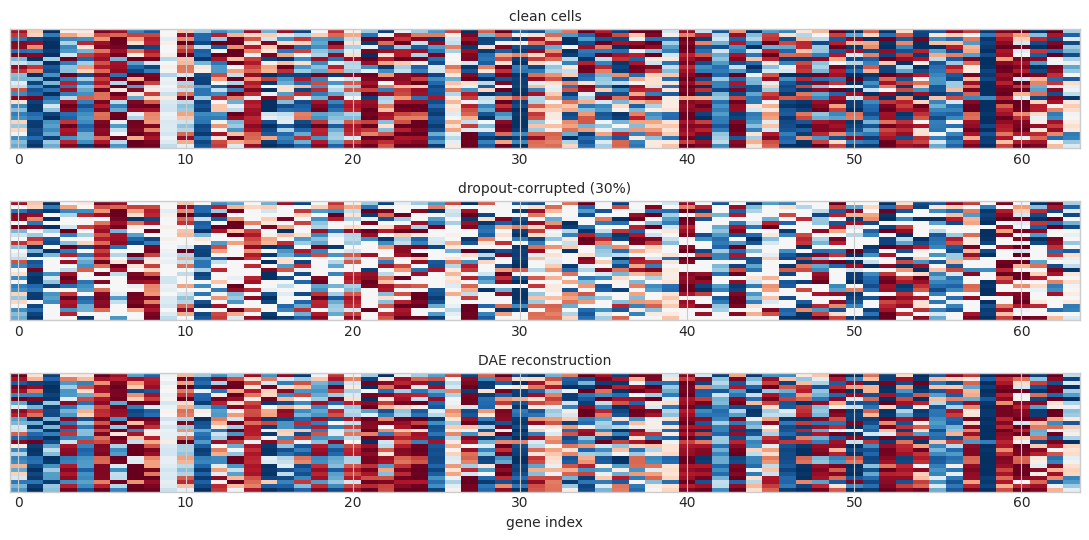

In [5]:
def dropout_corrupt(x, p_drop=0.3):
    mask = (torch.rand_like(x) > p_drop).float()
    return x * mask

class DenoisingAE(nn.Module):
    def __init__(self, D, hidden, L):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(D, hidden), nn.Tanh(),
                                 nn.Linear(hidden, L))
        self.dec = nn.Sequential(nn.Linear(L, hidden), nn.Tanh(),
                                 nn.Linear(hidden, D))
    def forward(self, x): return self.dec(self.enc(x))

dae = DenoisingAE(D, hidden=32, L=4)

def dae_loss(model, x):
    x_corr = dropout_corrupt(x, p_drop=0.3)
    return ((model(x_corr) - x) ** 2).mean()

hist_dae = train(dae, loader, n_epochs=200, lr=2e-3, loss_fn=dae_loss)

# Vanilla AE trained on clean data, for comparison
ae_clean = MLPAutoEncoder(D, hidden=32, L=4)
hist_clean = train(ae_clean, loader, n_epochs=200, lr=2e-3)

# Evaluate denoising on held-out data
X_val = X_t[val]
X_val_corr = dropout_corrupt(X_val, p_drop=0.3)
with torch.no_grad():
    recon_dae = dae(X_val_corr)
    recon_clean = ae_clean(X_val_corr)

mse_dae   = ((recon_dae   - X_val) ** 2).mean().item()
mse_clean = ((recon_clean - X_val) ** 2).mean().item()
mse_corr  = ((X_val_corr  - X_val) ** 2).mean().item()

print(f'corruption MSE                              : {mse_corr:.4f}')
print(f'AE trained on clean data, applied to noisy  : {mse_clean:.4f}')
print(f'DAE trained on noisy → clean                : {mse_dae:.4f}')

fig, axes = plt.subplots(3, 1, figsize=(11, 5.5))
n_show = 30
for ax, M, title in zip(
    axes,
    [X_val[:n_show].numpy(), X_val_corr[:n_show].numpy(), recon_dae[:n_show].numpy()],
    ['clean cells', 'dropout-corrupted (30%)', 'DAE reconstruction']):
    ax.imshow(M, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(title, fontsize=10); ax.set_yticks([])
axes[-1].set_xlabel('gene index')
plt.tight_layout(); plt.show()

**Score-function intuition** (§20.3.2). For Gaussian corruption with $\sigma \to 0$, the residual $r(\tilde{\mathbf{x}}) - \tilde{\mathbf{x}}$ approximates the score $\nabla_\mathbf{x} \log p(\mathbf{x})$ — it points uphill on the data density. We can visualise this as a vector field for a 2-d projection of the data.

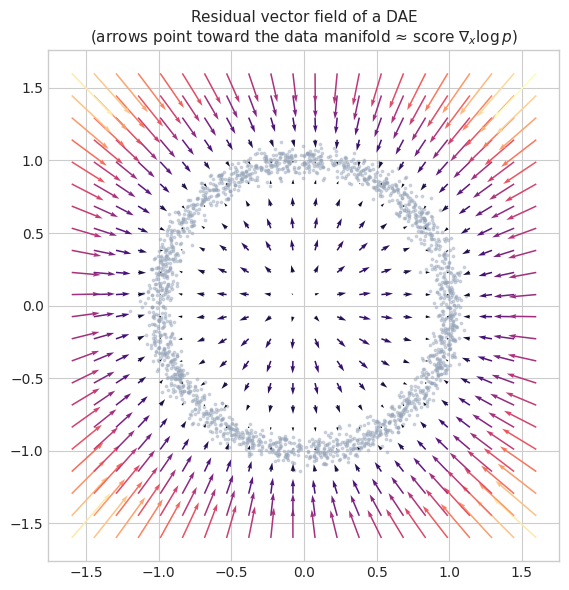

In [6]:
# Visualise the residual field of the DAE on the 2-d latent we learned in §3.
# Trick: build a tiny 2-d toy DAE so the field is interpretable.
class TinyDAE(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(2, hidden), nn.Tanh(), nn.Linear(hidden, 2))
        self.dec = nn.Sequential(nn.Linear(2, hidden), nn.Tanh(), nn.Linear(hidden, 2))
    def forward(self, x): return self.dec(self.enc(x))

# Build 2-d data: ring on the latent manifold
N2 = 2000
phi = np.random.uniform(0, 2*np.pi, N2)
data2 = np.stack([np.cos(phi), np.sin(phi)], axis=1) + 0.05 * np.random.randn(N2, 2)
data2 = torch.from_numpy(data2.astype(np.float32))

tiny = TinyDAE()
opt = torch.optim.Adam(tiny.parameters(), lr=2e-3)
sigma = 0.15
for ep in range(800):
    idx = torch.randint(0, N2, (256,))
    x = data2[idx]
    x_corr = x + sigma * torch.randn_like(x)
    loss = ((tiny(x_corr) - x) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()

# Score field
g = np.linspace(-1.6, 1.6, 22)
gx, gy = np.meshgrid(g, g)
grid = torch.from_numpy(np.stack([gx, gy], -1).reshape(-1, 2).astype(np.float32))
with torch.no_grad():
    res = (tiny(grid) - grid).numpy()
mag = np.linalg.norm(res, axis=1).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(data2[:, 0], data2[:, 1], s=3, color='#94a3b8', alpha=0.4)
ax.quiver(gx, gy, res[:, 0].reshape(gx.shape), res[:, 1].reshape(gx.shape),
          mag, cmap='magma', scale=10, width=0.003)
ax.set_aspect('equal')
ax.set_title('Residual vector field of a DAE\n(arrows point toward the data manifold ≈ score $\\nabla_x \\log p$)',
             fontsize=11)
plt.tight_layout(); plt.show()

## 5. Contractive Autoencoder (§20.3.3)

The contractive AE adds a Frobenius-norm penalty on the encoder Jacobian:

$$\mathcal{L}_{\text{CAE}} = \|\mathbf{x} - r(\mathbf{x})\|^2 + \lambda \left\|\frac{\partial f_e(\mathbf{x})}{\partial \mathbf{x}}\right\|_F^2.$$

This *contracts* most directions in input space, so the encoder only responds to the directions in which the data actually moves — those tangent to the manifold. We compute $\|J\|_F^2$ exactly via `torch.autograd.functional.jacobian` (cheap because $L \ll D$).

||J||_F^2  ·  vanilla AE : 5.884
||J||_F^2  ·  CAE        : 0.152
CAE encoder is 38.6× more contractive


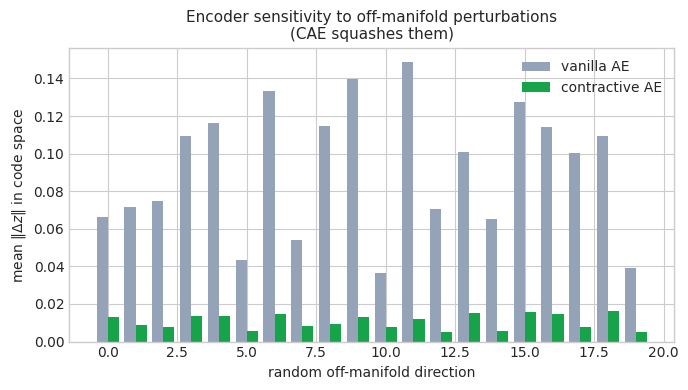

In [7]:
class ContractiveAE(nn.Module):
    def __init__(self, D, hidden, L):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(D, hidden), nn.Tanh(),
                                 nn.Linear(hidden, L), nn.Tanh())
        self.dec = nn.Sequential(nn.Linear(L, hidden), nn.Tanh(),
                                 nn.Linear(hidden, D))
    def forward(self, x): return self.dec(self.enc(x))

def jacobian_frobenius_sq(model_enc, x, n_samples=8):
    # ||dz/dx||_F^2 averaged over a few examples; backward-mode AD per output dim.
    idx = torch.randperm(x.size(0))[:n_samples]
    xb = x[idx].detach().requires_grad_(True)
    z = model_enc(xb)                                  # (n, L)
    L = z.size(1)
    fro_sq = 0.0
    for k in range(L):
        gk = torch.autograd.grad(z[:, k].sum(), xb, create_graph=True)[0]
        fro_sq = fro_sq + (gk ** 2).sum(dim=1)
    return fro_sq.mean()

cae = ContractiveAE(D, hidden=32, L=2)
opt = torch.optim.Adam(cae.parameters(), lr=2e-3)
lam = 1e-3
hist_cae = []
for ep in range(200):
    ep_loss = 0.0; ep_pen = 0.0
    for (xb,) in loader:
        opt.zero_grad()
        recon = cae(xb)
        rec_loss = ((recon - xb) ** 2).mean()
        pen = jacobian_frobenius_sq(cae.enc, xb, n_samples=16)
        loss = rec_loss + lam * pen
        loss.backward(); opt.step()
        ep_loss += rec_loss.item() * xb.size(0); ep_pen += pen.item() * xb.size(0)
    hist_cae.append((ep_loss / len(loader.dataset), ep_pen / len(loader.dataset)))

# Compare ||J||_F^2 to a vanilla AE (no penalty)
vanilla = MLPAutoEncoder(D, hidden=32, L=2)
train(vanilla, loader, n_epochs=200, lr=2e-3)

with torch.no_grad():
    pass  # placeholder — Jacobian needs grad
fro_vanilla = jacobian_frobenius_sq(vanilla.enc, X_t[val][:128]).item()
fro_cae     = jacobian_frobenius_sq(cae.enc,     X_t[val][:128]).item()
print(f'||J||_F^2  ·  vanilla AE : {fro_vanilla:.3f}')
print(f'||J||_F^2  ·  CAE        : {fro_cae:.3f}')
print(f'CAE encoder is {fro_vanilla/fro_cae:.1f}× more contractive')

# Show: small perturbations off the manifold get squashed in the latent
def perturb_and_encode(model, x, n_dirs=20, eps=0.3):
    rng = np.random.default_rng(1)
    dirs = rng.standard_normal((n_dirs, x.size(1))).astype(np.float32)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    with torch.no_grad():
        z0 = model.enc(x)
        out = []
        for d in dirs:
            zp = model.enc(x + eps * torch.from_numpy(d))
            out.append(((zp - z0) ** 2).sum(dim=1).sqrt().mean().item())
    return np.array(out)

x_probe = X_t[val][:64]
sens_van = perturb_and_encode(vanilla, x_probe)
sens_cae = perturb_and_encode(cae,     x_probe)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(np.arange(len(sens_van)) - 0.2, sens_van, width=0.4,
       color='#94a3b8', label='vanilla AE')
ax.bar(np.arange(len(sens_cae)) + 0.2, sens_cae, width=0.4,
       color='#16a34a', label='contractive AE')
ax.set_xlabel('random off-manifold direction')
ax.set_ylabel('mean $\\|\\Delta z\\|$ in code space')
ax.set_title('Encoder sensitivity to off-manifold perturbations\n(CAE squashes them)',
             fontsize=11)
ax.legend()
plt.tight_layout(); plt.show()

## 6. Sparse Autoencoder (§20.3.4)

A sparse AE keeps the bottleneck *over*-complete (many hidden units) but penalises the latent activations so most are silent on any given input. PML discusses two variants:

**(a) $\ell_1$ activity regularisation**:  $\Omega(\mathbf{z}) = \lambda \|\mathbf{z}\|_1$ — drives codes to exact zero, but can permanently kill units.

**(b) KL to a target firing rate** $p$ (e.g. $p = 0.05$): encourages each unit's average activation to be small without permanently disabling it. Used with sigmoid units so $z_k \in (0, 1)$ is interpretable as a probability:

$$\Omega(\mathbf{Z}) = \lambda \sum_k \mathrm{KL}(p \,\|\, q_k), \quad q_k = \tfrac{1}{N}\sum_n z_{n,k}.$$

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_83702/2446492189.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


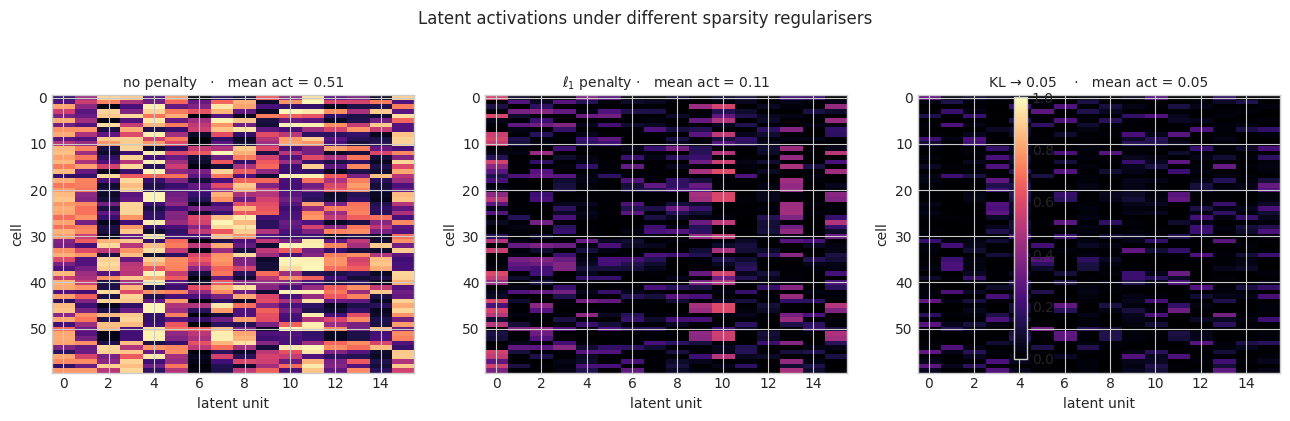

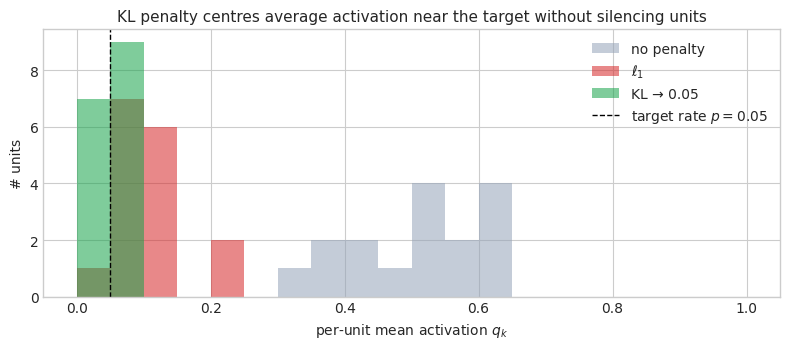

In [8]:
class SparseAE(nn.Module):
    def __init__(self, D, hidden, code, code_act='sigmoid'):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(D, hidden), nn.Tanh(),
                                 nn.Linear(hidden, code))
        self.dec = nn.Sequential(nn.Linear(code, hidden), nn.Tanh(),
                                 nn.Linear(hidden, D))
        self.code_act = code_act
    def encode(self, x):
        z = self.enc(x)
        return torch.sigmoid(z) if self.code_act == 'sigmoid' else z
    def forward(self, x):
        return self.dec(self.encode(x))

CODE = 16
def train_sparse(reg, lam, n_epochs=200):
    m = SparseAE(D, hidden=32, code=CODE, code_act='sigmoid')
    opt = torch.optim.Adam(m.parameters(), lr=2e-3)
    p_target = 0.05
    for ep in range(n_epochs):
        for (xb,) in loader:
            opt.zero_grad()
            z = m.encode(xb)
            recon = m.dec(z)
            rec = ((recon - xb) ** 2).mean()
            if reg == 'none':
                pen = torch.tensor(0.0)
            elif reg == 'l1':
                pen = z.abs().mean()
            elif reg == 'kl':
                q = z.mean(0).clamp(1e-6, 1 - 1e-6)
                p = torch.full_like(q, p_target)
                pen = (p * (p / q).log() + (1 - p) * ((1 - p) / (1 - q)).log()).sum()
            loss = rec + lam * pen
            loss.backward(); opt.step()
    return m

m_none = train_sparse('none', 0.0)
m_l1   = train_sparse('l1',   1e-2)
m_kl   = train_sparse('kl',   3e-2)

with torch.no_grad():
    Z_none = m_none.encode(X_t[val]).numpy()
    Z_l1   = m_l1.encode(X_t[val]).numpy()
    Z_kl   = m_kl.encode(X_t[val]).numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, Z, title in zip(
    axes,
    [Z_none, Z_l1, Z_kl],
    [f'no penalty   ·   mean act = {Z_none.mean():.2f}',
     f'$\\ell_1$ penalty ·   mean act = {Z_l1.mean():.2f}',
     f'KL → 0.05    ·   mean act = {Z_kl.mean():.2f}']):
    im = ax.imshow(Z[:60], aspect='auto', cmap='magma', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('latent unit'); ax.set_ylabel('cell')
plt.colorbar(im, ax=axes, shrink=0.85)
plt.suptitle('Latent activations under different sparsity regularisers', fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

# Histogram of mean activation per unit
fig, ax = plt.subplots(figsize=(8, 3.6))
for Z, lbl, c in [(Z_none, 'no penalty', '#94a3b8'),
                  (Z_l1,   '$\\ell_1$',     '#d62728'),
                  (Z_kl,   'KL → 0.05',  '#16a34a')]:
    means = Z.mean(0)
    ax.hist(means, bins=np.linspace(0, 1, 21), alpha=0.55, label=lbl, color=c)
ax.axvline(0.05, color='black', ls='--', lw=1, label='target rate $p=0.05$')
ax.set_xlabel('per-unit mean activation $q_k$'); ax.set_ylabel('# units')
ax.set_title('KL penalty centres average activation near the target without silencing units',
             fontsize=11)
ax.legend()
plt.tight_layout(); plt.show()

## 7. Variational Autoencoder (§20.3.5)

The VAE turns the AE into a **probabilistic generative model**:

- **Generative**: $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_L)$, $\mathbf{x} \sim \mathcal{N}(f_d(\mathbf{z}), \sigma^2 \mathbf{I})$.
- **Inference network**: $q_\phi(\mathbf{z}\mid\mathbf{x}) = \mathcal{N}(\mu_\phi(\mathbf{x}), \mathrm{diag}(\sigma_\phi^2(\mathbf{x})))$.

We maximise the ELBO

$$\mathrm{ELBO} = \mathbb{E}_{q_\phi}\!\big[\log p_\theta(\mathbf{x}\mid \mathbf{z})\big] - D_{\mathrm{KL}}\!\big(q_\phi(\mathbf{z}\mid \mathbf{x}) \,\|\, p(\mathbf{z})\big)$$

with the **reparameterization trick** $\mathbf{z} = \mu + \sigma \odot \boldsymbol{\epsilon}$ so gradients flow through the sample. For Gaussian $q$ and standard-normal prior, the KL has a closed form (Eq. 20.103):

$$D_{\mathrm{KL}}\big(\mathcal{N}(\mu, \mathrm{diag}\,\sigma^2)\,\|\,\mathcal{N}(\mathbf{0}, \mathbf{I})\big) = -\tfrac{1}{2}\sum_k \big[1 + \log \sigma_k^2 - \mu_k^2 - \sigma_k^2\big].$$

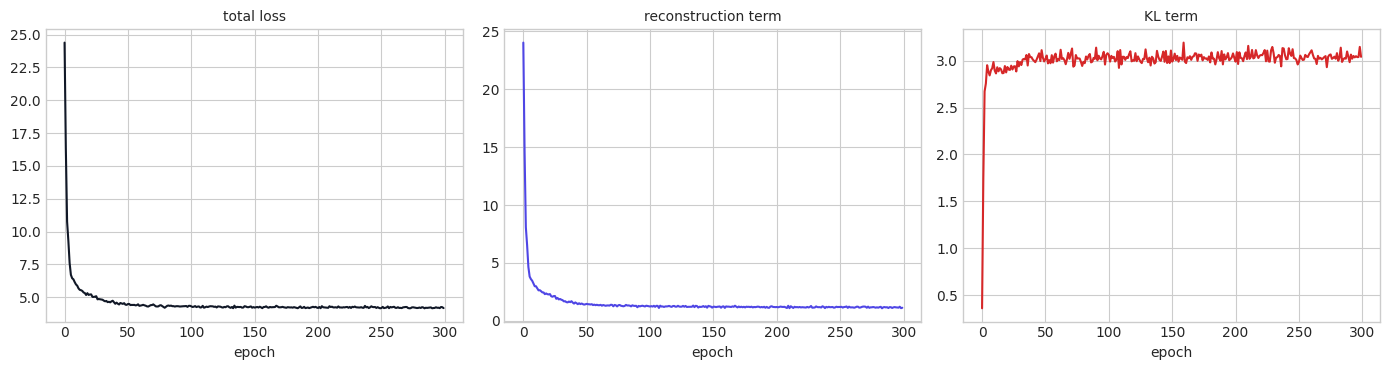

In [ ]:
class VAE(nn.Module):
    def __init__(self, D, hidden, L):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(D, hidden), nn.Tanh(),
                                     nn.Linear(hidden, hidden), nn.Tanh())
        self.fc_mu     = nn.Linear(hidden, L)
        self.fc_logvar = nn.Linear(hidden, L)
        self.decoder = nn.Sequential(nn.Linear(L, hidden), nn.Tanh(),
                                     nn.Linear(hidden, hidden), nn.Tanh(),
                                     nn.Linear(hidden, D))
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std) # Generate random noise that looks like std in shape
        return mu + eps * std
    def decode(self, z): return self.decoder(z)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = ((recon - x) ** 2).sum(dim=1).mean()                        # reconstruction
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()    # KL
    return recon_loss + beta * kl, recon_loss, kl

vae = VAE(D, hidden=64, L=2)
opt = torch.optim.Adam(vae.parameters(), lr=2e-3)

hist_total, hist_rec, hist_kl = [], [], []
for ep in range(300):
    tot = rec_s = kl_s = 0.0
    for (xb,) in loader:
        opt.zero_grad()
        recon, mu, logvar = vae(xb)
        loss, rec, kl = vae_loss(recon, xb, mu, logvar, beta=1.0)
        loss.backward(); opt.step()
        n = xb.size(0)
        tot += loss.item() * n; rec_s += rec.item() * n; kl_s += kl.item() * n
    hist_total.append(tot / n_tr); hist_rec.append(rec_s / n_tr); hist_kl.append(kl_s / n_tr)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(hist_total, color='#111827'); axes[0].set_title('total loss', fontsize=10)
axes[1].plot(hist_rec,   color='#4f46e5'); axes[1].set_title('reconstruction term', fontsize=10)
axes[2].plot(hist_kl,    color='#d62728'); axes[2].set_title('KL term', fontsize=10)
for ax in axes: ax.set_xlabel('epoch')
plt.tight_layout(); plt.show()

## 8. VAE vs AE — Why the Latent Distribution Matters

The key practical difference (§20.3.5.3): a deterministic AE only learns to decode the *exact* points it has encoded. The VAE encodes each input as a *distribution*, so the latent space stays smooth and continuous, which buys two new capabilities:

1. **Sampling**: drawing $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and decoding produces plausible new cells.
2. **Latent interpolation**: walking a straight line between two encodings produces smooth gene-expression gradients.

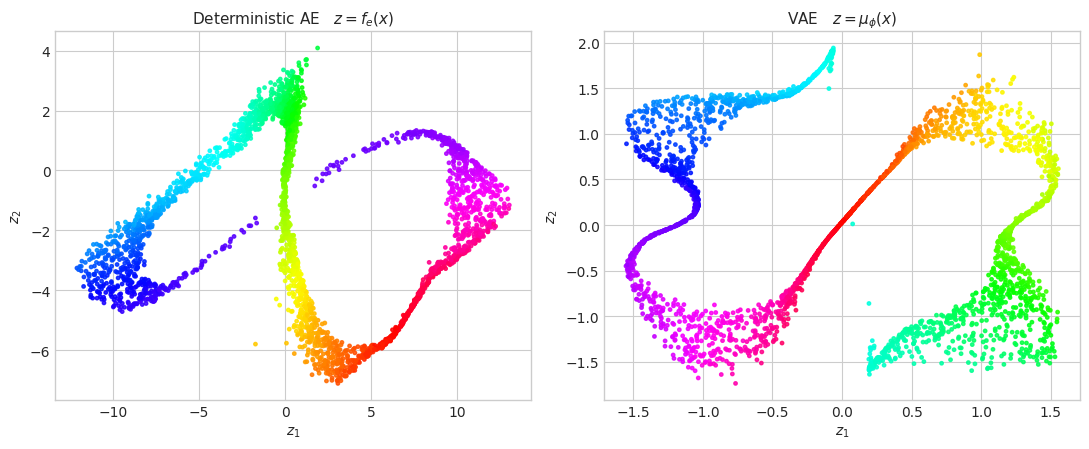

In [10]:
# Encode val cells with both models
with torch.no_grad():
    mu_vae, logvar_vae = vae.encode(X_t)
    Z_vae = mu_vae.numpy()
    Z_ae  = ae_nl.encode(X_t).numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, Z, title in zip(axes, [Z_ae, Z_vae],
                        ['Deterministic AE   $z = f_e(x)$',
                         'VAE   $z = \\mu_\\phi(x)$']):
    ax.scatter(Z[:, 0], Z[:, 1], c=theta, cmap='hsv', s=6, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
plt.tight_layout(); plt.show()

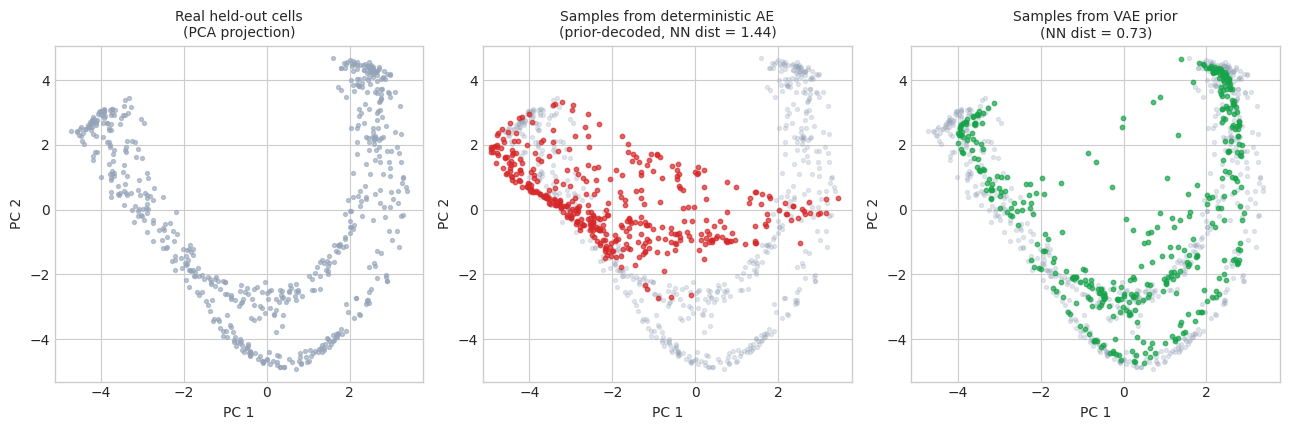

In [11]:
# (a) Sampling — VAE: ~ N(0, I); AE: nearest training-encoding hack
def density_score(samples, real):
    # mean nearest-neighbour distance from each sample to the real set
    s = samples[:, None, :] - real[None, :, :]
    d = np.sqrt((s ** 2).sum(-1))
    return d.min(axis=1).mean()

with torch.no_grad():
    z_prior = torch.randn(400, 2)
    x_vae_samples = vae.decode(z_prior).numpy()
    x_ae_samples  = ae_nl.decode(z_prior).numpy()           # AE has no prior, just feed N(0,I)
    x_real        = X_t[val].numpy()

# Compare via PCA projection
mu_real = X[tr].mean(0)
W_pca = np.linalg.eigh(np.cov(X[tr].T))[1][:, -2:]
proj_real = (x_real      - mu_real) @ W_pca
proj_vae  = (x_vae_samples - mu_real) @ W_pca
proj_ae   = (x_ae_samples  - mu_real) @ W_pca

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].scatter(proj_real[:, 0], proj_real[:, 1], s=8, alpha=0.6, color='#94a3b8')
axes[0].set_title('Real held-out cells\n(PCA projection)', fontsize=10)

axes[1].scatter(proj_real[:, 0], proj_real[:, 1], s=8, alpha=0.25, color='#94a3b8')
axes[1].scatter(proj_ae[:, 0],   proj_ae[:, 1],   s=10, alpha=0.7, color='#d62728')
axes[1].set_title(f'Samples from deterministic AE\n(prior-decoded, NN dist = {density_score(x_ae_samples, x_real):.2f})',
                  fontsize=10)

axes[2].scatter(proj_real[:, 0], proj_real[:, 1], s=8, alpha=0.25, color='#94a3b8')
axes[2].scatter(proj_vae[:, 0],  proj_vae[:, 1],  s=10, alpha=0.7, color='#16a34a')
axes[2].set_title(f'Samples from VAE prior\n(NN dist = {density_score(x_vae_samples, x_real):.2f})',
                  fontsize=10)

for ax in axes:
    ax.set_xlim(proj_real[:, 0].min()-0.4, proj_real[:, 0].max()+0.4)
    ax.set_ylim(proj_real[:, 1].min()-0.4, proj_real[:, 1].max()+0.4)
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout(); plt.show()

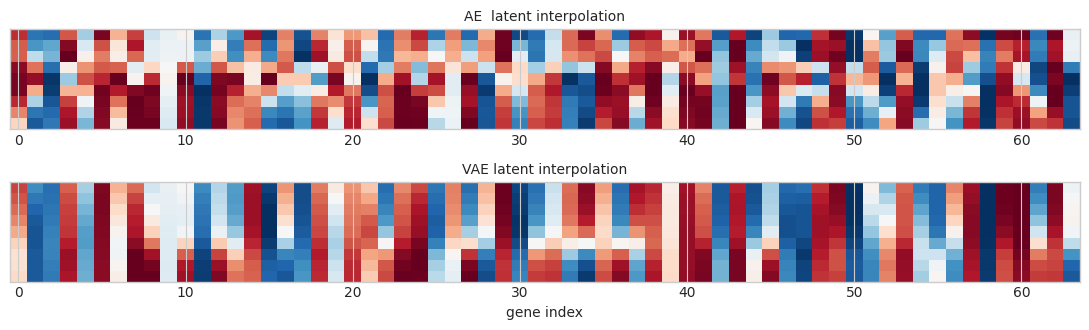

In [12]:
# (b) Latent interpolation between two cells
i, j = 7, 1234   # pick two cells on opposite sides of the cycle
x1 = X_t[i:i+1]; x2 = X_t[j:j+1]
alphas = np.linspace(0, 1, 9)

with torch.no_grad():
    mu1, _ = vae.encode(x1); mu2, _ = vae.encode(x2)
    z_ae1  = ae_nl.encode(x1); z_ae2 = ae_nl.encode(x2)
    interp_vae = torch.cat([vae.decode((1-a)*mu1 + a*mu2) for a in alphas])
    interp_ae  = torch.cat([ae_nl.decode((1-a)*z_ae1 + a*z_ae2) for a in alphas])

fig, axes = plt.subplots(2, 1, figsize=(11, 3.4))
for ax, M, ttl in zip(axes,
                      [interp_ae.numpy(), interp_vae.numpy()],
                      ['AE  latent interpolation', 'VAE latent interpolation']):
    ax.imshow(M, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_yticks([])
    ax.set_title(ttl, fontsize=10)
axes[-1].set_xlabel('gene index')
plt.tight_layout(); plt.show()

## Summary

- **General AE** $r = f_d \circ f_e$ trained to minimise $\|r(\mathbf{x})-\mathbf{x}\|^2$ — a non-linear extension of PCA / FA.
- **Linear bottleneck AE = PCA**: trained without nonlinearities, the AE's reconstruction loss converges to the PCA bound and recovers the same subspace.
- **Nonlinear AE > PCA** when the data manifold is curved: it can "unroll" the cell-cycle ring into a strip while PCA cannot.
- **DAE** trains $r(\tilde{\mathbf{x}}) \to \mathbf{x}$ with corrupted inputs; the residual approximates the score $\nabla_\mathbf{x} \log p(\mathbf{x})$, and DAEs are the natural fit for scRNA-seq dropout imputation.
- **CAE** penalises $\|\partial f_e/\partial \mathbf{x}\|_F^2$ — encoder responds only to on-manifold variation.
- **Sparse AE**: $\ell_1$ kills units, KL-to-target keeps every unit alive but firing rarely.
- **VAE**: probabilistic AE with ELBO + reparameterization. The KL term forces $q_\phi(\mathbf{z}\mid \mathbf{x})$ to overlap with the prior, making the latent space *smooth* — so we can sample and interpolate, neither of which a deterministic AE supports.

This positions us for §20.4 (manifold learning), where the point is to learn the latent subspace *without* having to commit to a parametric encoder.